In [2]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

LAMBDA vs r and mse

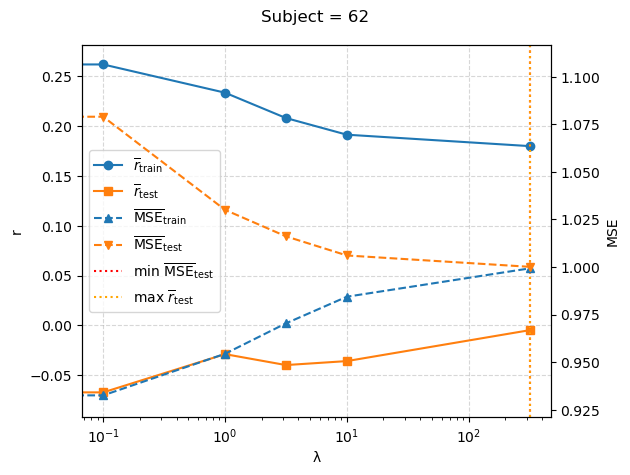

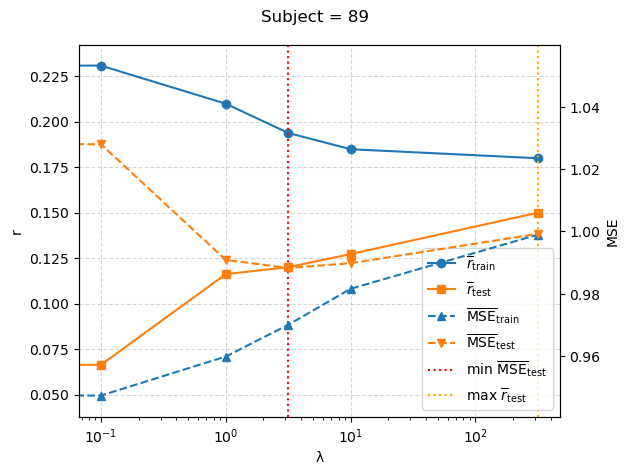

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_5seconds_window_SLOW"

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SUBJECTS = [62, 89]
for sub in SUBJECTS:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        #print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    # Ensure numeric & sort by lam
    num_cols = ["lam", "mean_train_mse", "mean_test_mse",  "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=num_cols).sort_values("lam")

    # ---- find best lambda by test MSE (min) and test r (max) ----
    idx_best_mse = df["mean_test_mse"].idxmin()
    lam_best_mse = df.loc[idx_best_mse, "lam"]

    idx_best_r = df["mean_test_r"].idxmax()
    lam_best_r = df.loc[idx_best_r, "lam"]

    # One figure with two y-axes
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()  # second y-axis sharing same x

    # Left axis: correlations
    l1, = ax1.plot(df["lam"], df["mean_train_r"], marker="o",label=r"$\overline{r}_{\text{train}}$")
    l2, = ax1.plot(df["lam"], df["mean_test_r"], marker="s", label=r"$\overline{r}_{\text{test}}$")

    ax1.set_xlabel("λ")
    ax1.set_ylabel("r")
    ax1.set_xscale("log")

    # Right axis: MSE
    l3, = ax2.plot(df["lam"], df["mean_train_mse"], marker="^", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{train}}$")
    l4, = ax2.plot(df["lam"], df["mean_test_mse"], marker="v", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{test}}$")
    ax2.set_ylabel("MSE")

    # ---- vertical lines for best λs ----
    v1 = ax1.axvline(lam_best_mse, linestyle=":", linewidth=1.5, color="red", label=r"min $\overline{\text{MSE}}_{\text{test}}$")
    v2 = ax1.axvline(lam_best_r, linestyle=":", linewidth=1.5, color="orange", label=r"max $\overline{r}_{\text{test}}$")

    # Title & grid
    fig.suptitle(f"Subject = {sub}")
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Single combined legend
    lines = [l1, l2, l3, l4, v1, v2]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="best")

    fig.tight_layout()


[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\3seconds_window_SLOW\order_ridge_SLOW_k35.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\3seconds_window_SLOW\order_ridge_SLOW_k46.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\3seconds_window_SLOW\order_ridge_SLOW_k60.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\3seconds_window_SLOW\order_ridge_SLOW_k68.csv
Best λ (min mean_test_mse): 3.1622776601683795
Best λ (max mean_test_r): 1.0


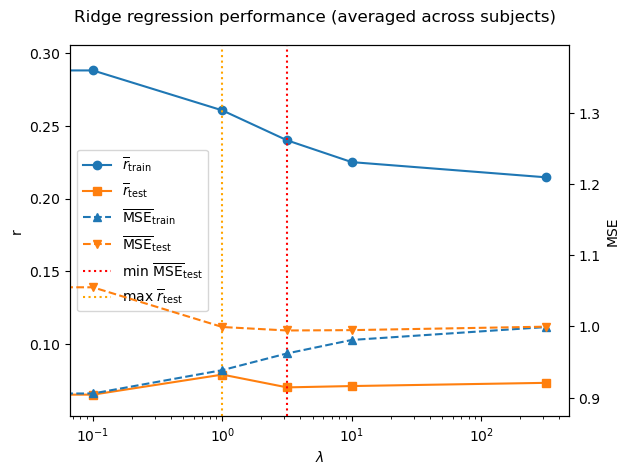

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# HERE I delete the lambda 31.622776601683796 because not all subjects have it, and other subjects do not have 100 or 316.2277 so I move everything to 316.227766016838

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\3seconds_window_SLOW"

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

all_dfs = []

for sub in SUBJECTS:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    num_cols = ["lam", "mean_train_mse", "mean_test_mse",  "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # === NEW BLOCK: tweak λ values per subject =========================
    lam_drop = 31.622776601683796
    lam_100  = 100.0
    lam_316  = 316.227766016838

    # 1) Drop all rows with λ = 31.622776601683796
    df = df[~np.isclose(df["lam"], lam_drop)]

    # 2 & 3) Handle 100 vs 316.227766016838
    has_100 = np.isclose(df["lam"], lam_100).any()
    has_316 = np.isclose(df["lam"], lam_316).any()

    if has_100 and has_316:
        # If both present: drop λ = 100 for this subject
        df = df[~np.isclose(df["lam"], lam_100)]
    elif has_100 and not has_316:
        # If only 100 present: move those rows to λ = 316.227...
        df.loc[np.isclose(df["lam"], lam_100), "lam"] = lam_316
    # if only 316 present or neither present, do nothing
    # ===================================================================

    df = df.dropna(subset=num_cols).sort_values("lam")
    df["subject"] = sub
    all_dfs.append(df)

# ---- Combine all subjects ----
df_all = pd.concat(all_dfs, ignore_index=True)

# ---- Aggregate across subjects per λ ----
agg = (
    df_all
    .groupby("lam")
    .agg(
        mean_train_mse=("mean_train_mse", "mean"),
        mean_test_mse=("mean_test_mse", "mean"),
        mean_train_r=("mean_train_r", "mean"),
        mean_test_r=("mean_test_r", "mean"),
        # stds (optional)
        std_train_mse=("mean_train_mse", "std"),
        std_test_mse=("mean_test_mse", "std"),
        std_train_r=("mean_train_r", "std"),
        std_test_r=("mean_test_r", "std"),
        n=("subject", "nunique")
    )
    .reset_index()
)

# ---- find λ with min test MSE and max test r (on the averaged curves) ----
idx_best_mse = agg["mean_test_mse"].idxmin()
lam_best_mse = agg.loc[idx_best_mse, "lam"]

idx_best_r = agg["mean_test_r"].idxmax()
lam_best_r = agg.loc[idx_best_r, "lam"]

print("Best λ (min mean_test_mse):", lam_best_mse)
print("Best λ (max mean_test_r):", lam_best_r)

# ---- Plot ----
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Left y-axis: correlations
l1, = ax1.plot(
    agg["lam"], agg["mean_train_r"], marker="o",
    label=r"$\overline{r}_{\text{train}}$"
)
l2, = ax1.plot(
    agg["lam"], agg["mean_test_r"], marker="s",
    label=r"$\overline{r}_{\text{test}}$"
)
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("r")
ax1.set_xscale("log")

# Right y-axis: MSE
l3, = ax2.plot(
    agg["lam"], agg["mean_train_mse"], marker="^", linestyle="--",
    label=r"$\overline{\text{MSE}}_{\text{train}}$"
)
l4, = ax2.plot(
    agg["lam"], agg["mean_test_mse"], marker="v", linestyle="--",
    label=r"$\overline{\text{MSE}}_{\text{test}}$"
)
ax2.set_ylabel("MSE")

# ---- vertical lines for best λs ----
v1 = ax1.axvline(
    lam_best_mse, linestyle=":", linewidth=1.5, color="red",
    label=r"min $\overline{\text{MSE}}_{\text{test}}$"
)
v2 = ax1.axvline(
    lam_best_r, linestyle=":", linewidth=1.5, color="orange",
    label=r"max $\overline{r}_{\text{test}}$"
)

# Legend combining all lines
lines = [l1, l2, l3, l4, v1, v2]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="best")

fig.suptitle("Ridge regression performance (averaged across subjects)")
fig.tight_layout()
plt.show()


[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\\1_5seconds_window_SLOW\order_ridge_SLOW_k35.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\\1_5seconds_window_SLOW\order_ridge_SLOW_k46.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\\1_5seconds_window_SLOW\order_ridge_SLOW_k68.csv
[skip] File not found: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\\1_5seconds_window_SLOW\order_ridge_SLOW_k69.csv


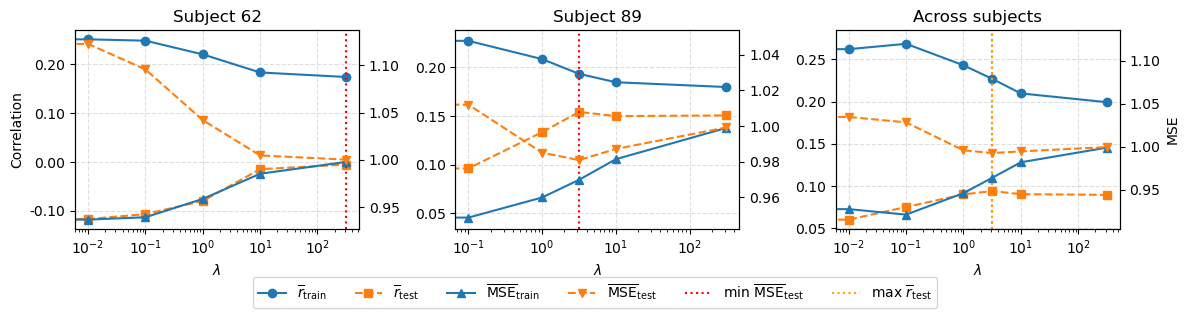

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\\1_5seconds_window_SLOW"

# all subjects you want to include in the average
SUBJECTS_ALL = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

# the individual subjects you want panels for
SUBJECTS_TO_SHOW = [62, 89]

all_dfs = []
per_subject = {}

for sub in SUBJECTS_ALL:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    num_cols = ["lam", "mean_train_mse", "mean_test_mse",
                "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # === λ harmonisation block (your existing logic) =================
    lam_drop = 31.622776601683796
    lam_100  = 100.0
    lam_316  = 316.227766016838

    # drop λ = 31.62...
    df = df[~np.isclose(df["lam"], lam_drop)]

    has_100 = np.isclose(df["lam"], lam_100).any()
    has_316 = np.isclose(df["lam"], lam_316).any()

    if has_100 and has_316:
        df = df[~np.isclose(df["lam"], lam_100)]
    elif has_100 and not has_316:
        df.loc[np.isclose(df["lam"], lam_100), "lam"] = lam_316
    # =================================================================

    df = df.dropna(subset=num_cols).sort_values("lam")
    df["subject"] = sub
    all_dfs.append(df)

    if sub in SUBJECTS_TO_SHOW:
        per_subject[sub] = df.copy()

# ---------- Combine all subjects for the group-average panel ----------
df_all = pd.concat(all_dfs, ignore_index=True)

agg = (
    df_all
    .groupby("lam")
    .agg(
        mean_train_mse=("mean_train_mse", "mean"),
        mean_test_mse=("mean_test_mse", "mean"),
        mean_train_r=("mean_train_r", "mean"),
        mean_test_r=("mean_test_r", "mean"),
        std_train_mse=("mean_train_mse", "std"),
        std_test_mse=("mean_test_mse", "std"),
        std_train_r=("mean_train_r", "std"),
        std_test_r=("mean_test_r", "std"),
        n=("subject", "nunique")
    )
    .reset_index()
)

# best λ on the averaged curves
idx_best_mse_group = agg["mean_test_mse"].idxmin()
lam_best_mse_group = agg.loc[idx_best_mse_group, "lam"]

idx_best_r_group = agg["mean_test_r"].idxmax()
lam_best_r_group = agg.loc[idx_best_r_group, "lam"]

# best λ (min test MSE) for each individual subject
best_lam_subj = {
    sub: df.loc[df["mean_test_mse"].idxmin(), "lam"]
    for sub, df in per_subject.items()
}

# ---------- Global y-ranges (across all subjects) ----------
all_r_vals = np.r_[
    df_all["mean_train_r"].values,
    df_all["mean_test_r"].values
]
all_mse_vals = np.r_[
    df_all["mean_train_mse"].values,
    df_all["mean_test_mse"].values
]


# ---------- Make the 3-panel figure ----------
n_panels = len(SUBJECTS_TO_SHOW) + 1  # +1 for the group-average
fig, axes = plt.subplots(1, n_panels, figsize=(4.0 * n_panels, 3.2), sharex=False)

# if only one panel, axes is not an array; make it iterable
if n_panels == 1:
    axes = [axes]

all_lines = []

# ---- Panels for individual subjects ----
for j, sub in enumerate(SUBJECTS_TO_SHOW):
    ax = axes[j]
    df = per_subject[sub]
    lam = df["lam"].values

    # left y-axis: correlations
    ax.set_xscale("log")
    line_r_tr, = ax.plot(lam, df["mean_train_r"], marker="o", linestyle="-",
                         label=r"$\overline{r}_{\mathrm{train}}$")
    line_r_te, = ax.plot(lam, df["mean_test_r"], marker="s", linestyle="--",
                         label=r"$\overline{r}_{\mathrm{test}}$")
    ax.set_xlabel(r"$\lambda$")
    if j == 0:
        ax.set_ylabel("Correlation")
    ax.set_title(f"Subject {sub}")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # right y-axis: MSE
    ax2 = ax.twinx()
    line_mse_tr, = ax2.plot(lam, df["mean_train_mse"], marker="^", linestyle="-",
                            label=r"$\overline{\mathrm{MSE}}_{\mathrm{train}}$")
    line_mse_te, = ax2.plot(lam, df["mean_test_mse"], marker="v", linestyle="--",
                            label=r"$\overline{\mathrm{MSE}}_{\mathrm{test}}$")
    if j == n_panels - 1:
        ax2.set_ylabel("MSE")

    # vertical line: min test MSE
    v_sub = ax.axvline(
        best_lam_subj[sub],
        linestyle=":",
        linewidth=1.5,
        color="red",
        label=r"min $\overline{\mathrm{MSE}}_{\mathrm{test}}$"
    )

    all_lines.extend([line_r_tr, line_r_te, line_mse_tr, line_mse_te, v_sub])

# ---- Panel for group-average curves ----
ax = axes[-1]
lam = agg["lam"].values

ax.set_xscale("log")
line_r_tr, = ax.plot(lam, agg["mean_train_r"], marker="o", linestyle="-",
                     label=r"$\overline{r}_{\mathrm{train}}$")
line_r_te, = ax.plot(lam, agg["mean_test_r"], marker="s", linestyle="--",
                     label=r"$\overline{r}_{\mathrm{test}}$")
ax.set_xlabel(r"$\lambda$")
ax.set_title("Across subjects")
ax.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax2 = ax.twinx()
line_mse_tr, = ax2.plot(lam, agg["mean_train_mse"], marker="^", linestyle="-",
                        label=r"$\overline{\mathrm{MSE}}_{\mathrm{train}}$")
line_mse_te, = ax2.plot(lam, agg["mean_test_mse"], marker="v", linestyle="--",
                        label=r"$\overline{\mathrm{MSE}}_{\mathrm{test}}$")
ax2.set_ylabel("MSE")

v1 = ax.axvline(
    lam_best_mse_group, linestyle=":", linewidth=1.5, color="red",
    label=r"min $\overline{\mathrm{MSE}}_{\mathrm{test}}$"
)
v2 = ax.axvline(
    lam_best_r_group, linestyle=":", linewidth=1.5, color="orange",
    label=r"max $\overline{r}_{\mathrm{test}}$"
)

all_lines.extend([line_r_tr, line_r_te, line_mse_tr, line_mse_te, v1, v2])

# ---------- Global legend (unique labels, like in your sim figure) ----------
seen = set()
uniq_lines = []
uniq_labels = []
for line in all_lines:
    lab = line.get_label()
    if lab not in seen:
        seen.add(lab)
        uniq_lines.append(line)
        uniq_labels.append(lab)

fig.legend(
    uniq_lines,
    uniq_labels,
    loc="lower center",
    ncol=len(uniq_lines),      # one row
    bbox_to_anchor=(0.5, 0)
)

plt.tight_layout(rect=[0, 0.07, 1, 1])  # leave room for legend at bottom
# plt.savefig("ridge_real_subjects_and_group.png", dpi=300)
plt.show()


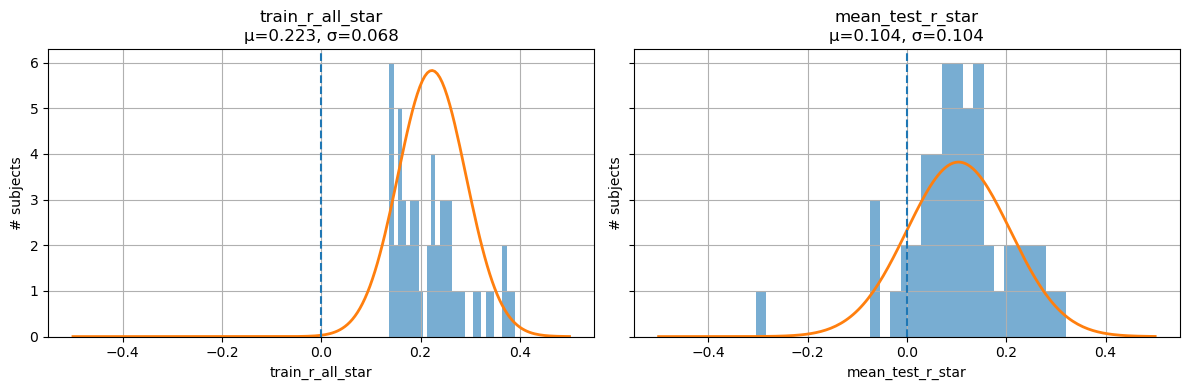

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

path = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_5seconds_window_SLOW\dfk_ridge_UPDATE.csv"
df = pd.read_csv(path)

cols = ["train_r_all_star", "mean_test_r_star"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, cols):
    vals = df[col].dropna()
    
    # Histogram as density
    ax.hist(vals, bins=30, alpha=0.6)
    
    # Fit normal distribution
    mu, sigma = norm.fit(vals)
    
    # X range for the curve
    x_min, x_max = vals.min(), vals.max()
    x_min, x_max = -0.5, 0.5
    x = np.linspace(x_min, x_max, 200)
    pdf = norm.pdf(x, mu, sigma)
    
    # Plot fitted normal curve
    ax.plot(x, pdf, linewidth=2)
    
    # Reference at 0
    ax.axvline(0, linestyle="--")
    
    ax.set_title(f"{col}\nμ={mu:.3f}, σ={sigma:.3f}")
    ax.set_xlabel(col)
    ax.grid(True)
    ax.set_ylabel("# subjects")

plt.tight_layout()
plt.show()


In [9]:
import numpy as np
from scipy import stats

for col in ["train_r_all_star", "mean_test_r_star"]:
    vals = df[col].dropna()
    mean = vals.mean()
    std = vals.std(ddof=1)
    n = len(vals)
    t_stat, p_val = stats.ttest_1samp(vals, 0, alternative='greater')

    print(f"\nColumn: {col}")
    print(f"  n = {n}")
    print(f"  mean = {mean:.4f}, std = {std:.4f}")
    print(f"  t-stat = {t_stat:.3f}, p-value = {p_val:.5f}")



Column: train_r_all_star
  n = 53
  mean = 0.2229, std = 0.0691
  t-stat = 23.479, p-value = 0.00000

Column: mean_test_r_star
  n = 53
  mean = 0.1040, std = 0.1054
  t-stat = 7.187, p-value = 0.00000



[Combined]
  Train λ=0 n=53 mean=0.1216
  Train λ*  n=53 mean=0.1116
  Held-out files found: 53
  Held-out λ=0     n=53 mean=0.0690
  Held-out best λ≠0 n=53 mean=0.0769

[Tonic]
  Train λ=0 n=53 mean=0.2754
  Train λ*  n=53 mean=0.2287
  Held-out files found: 53
  Held-out λ=0     n=53 mean=0.0735
  Held-out best λ≠0 n=53 mean=0.1179

[Phasic]
  Train λ=0 n=53 mean=0.2545
  Train λ*  n=53 mean=0.2234
  Held-out files found: 53
  Held-out λ=0     n=53 mean=0.1199
  Held-out best λ≠0 n=53 mean=0.1431


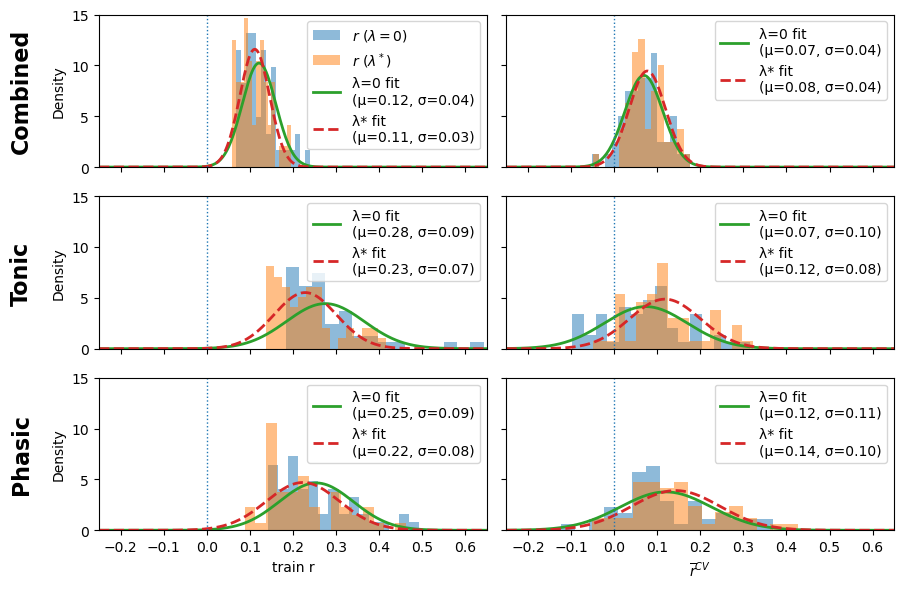

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------
# Helpers
# -----------------------
def _first_existing_col(df, candidates, name_for_error="column"):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {name_for_error}. Tried: {candidates}. Found columns: {list(df.columns)}")

def load_train_arrays(base_dir, train_csv):
    df_train = pd.read_csv(os.path.join(base_dir, train_csv))

    # robust column selection (in case naming differs slightly)
    col_star = _first_existing_col(df_train,
                                  ["train_r_all_star", "train_r_star", "train_r_star_all"],
                                  "train star r column")
    col_l0   = _first_existing_col(df_train,
                                  ["train_r_all_lam0", "train_r_lam0", "train_r_all_0"],
                                  "train lam0 r column")

    train_star = df_train[col_star].dropna().to_numpy()
    train_lam0 = df_train[col_l0].dropna().to_numpy()
    return train_lam0, train_star

def load_heldout_arrays(pattern, best_by="mean_test_r", exclude_lam0_for_best=True):
    files = sorted(glob.glob(pattern))
    lam0_vals = []
    best_vals = []

    for f in files:
        df = pd.read_csv(f)
        if "lam" not in df.columns or "mean_test_r" not in df.columns:
            print(f"Skipping {f} (missing lam/mean_test_r)")
            continue

        df = df.copy()
        df["lam"] = df["lam"].astype(float)

        # λ = 0
        lam0_row = df.loc[df["lam"] == 0.0]
        if not lam0_row.empty:
            lam0_vals.append(float(lam0_row["mean_test_r"].iloc[0]))

        # best non-zero λ (by max mean_test_r, like your code)
        cand = df.loc[df["lam"] != 0.0] if exclude_lam0_for_best else df
        if not cand.empty:
            best_row = cand.loc[cand[best_by].idxmax()]
            best_vals.append(float(best_row["mean_test_r"]))

    return np.array(lam0_vals), np.array(best_vals), len(files)

def plot_hist_with_gauss(ax, a, b, x, bins, title, xlabel,
                         show_legend=True, include_hist_labels=True):
    # hist (only label them when include_hist_labels=True)
    lab0 = r"$r\ (\lambda=0)$" if include_hist_labels else "_nolegend_"
    lab1 = r"$r\ (\lambda^*)$" if include_hist_labels else "_nolegend_"

    ax.hist(a, bins=bins, density=True, alpha=0.5, label=lab0)
    ax.hist(b, bins=bins, density=True, alpha=0.5, label=lab1)

    # gaussian fits (always in legend)
    def _fit(arr):
        if len(arr) < 2:
            return np.nan, np.nan
        mu, sig = norm.fit(arr)
        return mu, max(sig, 1e-6)

    mu_a, sig_a = _fit(a)
    mu_b, sig_b = _fit(b)

    if np.isfinite(mu_a):
        ax.plot(x, norm.pdf(x, mu_a, sig_a), linewidth=2,
                label=f"λ=0 fit\n(μ={mu_a:.2f}, σ={sig_a:.2f})")
    if np.isfinite(mu_b):
        ax.plot(x, norm.pdf(x, mu_b, sig_b), linewidth=2, linestyle="--",
                label=f"λ* fit\n(μ={mu_b:.2f}, σ={sig_b:.2f})")

    ax.axvline(0, linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)

    if show_legend:
        ax.legend()


# -----------------------
# Config
# -----------------------
ROOT = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg"

conditions = [
    # row_label, base_dir, train_csv, heldout_pattern
    ("Combined",
     os.path.join(ROOT, "2seconds_window_ALL"),
     "dfk_ridge_ALL.csv",
     os.path.join(ROOT, "2seconds_window_ALL",  "order_ridge_ALL_k*.csv")),

    ("Tonic",
     os.path.join(ROOT, "2seconds_window_SLOW"),
     "dfk_ridge.csv",
     os.path.join(ROOT, "2seconds_window_SLOW", "order_ridge_SLOW_k*.csv")),

    ("Phasic",
     os.path.join(ROOT, "1seconds_window_FAST"),
     "dfk_ridge.csv",
     os.path.join(ROOT, "1seconds_window_FAST", "order_ridge_FAST_k*.csv")),
]

# Plot settings (global x-axis)
bins = 15
x_min, x_max = -0.25, 0.65
x = np.linspace(x_min, x_max, 300)

# -----------------------
# Plot 3x2
# -----------------------
fig, axes = plt.subplots(3, 2, figsize=(9, 6), sharex=True, sharey="row")

# column titles
axes[0, 0].set_title("Train")
axes[0, 1].set_title("Held-out")

row_ymax = [0.0, 0.0, 0.0]  # track per-row max y to equalize later

for r, (row_label, base_dir, train_csv, held_pattern) in enumerate(conditions):
    # --- load data ---
    train_lam0, train_star = load_train_arrays(base_dir, train_csv)
    lam0_vals, best_non0_vals, n_files = load_heldout_arrays(
        held_pattern,
        best_by="mean_test_r",
        exclude_lam0_for_best=True
    )

    print(f"\n[{row_label}]")
    print(f"  Train λ=0 n={len(train_lam0)} mean={np.mean(train_lam0):.4f}")
    print(f"  Train λ*  n={len(train_star)} mean={np.mean(train_star):.4f}")
    print(f"  Held-out files found: {n_files}")
    print(f"  Held-out λ=0     n={len(lam0_vals)} mean={np.mean(lam0_vals):.4f}")
    print(f"  Held-out best λ≠0 n={len(best_non0_vals)} mean={np.mean(best_non0_vals):.4f}")

    # TRAIN panel
    axL = axes[r, 0]
    include_hist = (r == 0 and 0 == 0)   # only top-left
    plot_hist_with_gauss(
        axL, train_lam0, train_star, x, bins,
        title="",
        xlabel="train r" if r == 2 else "",
        show_legend=True,
        include_hist_labels=include_hist
    )
    axL.set_xlim(x_min, x_max)
    axL.set_ylim(0, 15)
    axL.set_ylabel("Density")

    # HELD-OUT panel
    axR = axes[r, 1]
    plot_hist_with_gauss(
        axR, lam0_vals, best_non0_vals, x, bins,
        title="",
        xlabel=r"$\overline{r}^{CV}$" if r == 2 else "",
        show_legend=True,
        include_hist_labels=False   # never show histogram labels here
    )
    axR.set_xlim(x_min, x_max)
    axR.set_ylim(0, 15)
    # --- row label on far left (as a "first column") ---
    # place text just outside the left plot
    axL.text(-0.2, 0.5, row_label, transform=axL.transAxes,
            ha="center", va="center", rotation=90,
            fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


In [4]:
import os, glob, re
import numpy as np
import pandas as pd
from scipy import stats

# ---------- Fisher z transform ----------
def fisher_z(r, eps=1e-7):
    r = np.asarray(r, dtype=float)
    r = np.clip(r, -1 + eps, 1 - eps)
    return np.arctanh(r)

def inv_fisher_z(z):
    return np.tanh(z)

# ---------- one-sample t-test + 95% CI ----------
def one_sample_t_test_ci(data, mu0=0.0, alpha=0.05, alternative="two-sided"):
    data = np.asarray(data, dtype=float)
    n = len(data)
    mean = data.mean()
    sd = data.std(ddof=1)
    se = sd / np.sqrt(n)
    df = n - 1

    t_stat = (mean - mu0) / se
    p_two = stats.t.sf(np.abs(t_stat), df) * 2.0

    if alternative == "greater":
        p_val = p_two / 2.0 if mean > mu0 else 1.0 - p_two / 2.0
    elif alternative == "less":
        p_val = p_two / 2.0 if mean < mu0 else 1.0 - p_two / 2.0
    else:
        p_val = p_two

    t_crit = stats.t.ppf(1.0 - alpha/2.0, df)
    ci_low = mean - t_crit * se
    ci_high = mean + t_crit * se

    return {"n": n, "mean": mean, "sd": sd, "se": se, "t": t_stat, "df": df, "p": p_val, "ci": (ci_low, ci_high)}

# ---------- Load paired λ=0 and best λ≠0 from subject files ----------
def load_paired_lam0_best(pattern, best_mode="max_r", exclude_lam0_for_best=True):
    """
    Returns paired arrays (lam0_vals, best_vals) aligned by subject file.
    best_mode: "max_r" (best by max mean_test_r) or "min_mse" (best by min mean_test_mse)
    """
    files = sorted(glob.glob(pattern))
    lam0_vals, best_vals, subs_used = [], [], []

    for f in files:
        df = pd.read_csv(f)

        if "lam" not in df.columns or "mean_test_r" not in df.columns:
            continue
        df = df.copy()
        df["lam"] = df["lam"].astype(float)

        # λ=0 row
        lam0_row = df.loc[df["lam"] == 0.0]
        if lam0_row.empty:
            continue
        lam0_r = float(lam0_row["mean_test_r"].iloc[0])

        # best row
        cand = df.loc[df["lam"] != 0.0] if exclude_lam0_for_best else df
        if cand.empty:
            continue

        if best_mode == "max_r":
            best_row = cand.loc[cand["mean_test_r"].idxmax()]
        elif best_mode == "min_mse":
            if "mean_test_mse" not in cand.columns:
                continue
            best_row = cand.loc[cand["mean_test_mse"].idxmin()]
        else:
            raise ValueError("best_mode must be 'max_r' or 'min_mse'")

        best_r = float(best_row["mean_test_r"])

        lam0_vals.append(lam0_r)
        best_vals.append(best_r)

        # subject number (optional)
        m = re.search(r"_k(\d+)\.csv$", os.path.basename(f))
        subs_used.append(int(m.group(1)) if m else None)

    return np.array(lam0_vals), np.array(best_vals), np.array(subs_used), len(files)

# =========================
# Run the tests for 3 cases
# =========================
ALT = "two-sided"   # "two-sided" is safest default

ROOT = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg"
cases = {
    "Combined": os.path.join(ROOT, "2seconds_window_ALL",  "order_ridge_ALL_k*.csv"),
    "Tonic":    os.path.join(ROOT, "2seconds_window_SLOW", "order_ridge_SLOW_k*.csv"),
    "Phasic":   os.path.join(ROOT, "1seconds_window_FAST", "order_ridge_FAST_k*.csv"),
}

rows = []

for name, pattern in cases.items():
    lam0_vals, best_vals, subs, n_files = load_paired_lam0_best(
        pattern,
        best_mode="max_r",              # matches your histogram selection
        exclude_lam0_for_best=True
    )

    if len(lam0_vals) == 0:
        print(f"{name}: no paired subjects found.")
        continue

    z_lam0 = fisher_z(lam0_vals)
    z_best = fisher_z(best_vals)
    z_diff = z_best - z_lam0

    sd_lam0_r = np.std(lam0_vals, ddof=1)
    sd_best_r = np.std(best_vals, ddof=1)
    sd_dz     = np.std(z_diff, ddof=1)   # SD on Fisher-z difference scale


    res_lam0 = one_sample_t_test_ci(z_lam0, mu0=0.0, alternative=ALT)
    res_best = one_sample_t_test_ci(z_best, mu0=0.0, alternative=ALT)
    res_diff = one_sample_t_test_ci(z_diff, mu0=0.0, alternative=ALT)

    # Wilcoxon on Δz (paired nonparametric)
    w = stats.wilcoxon(z_diff, alternative=ALT)

    # Back-transform CI for means (nice for reporting)
    ci_r_lam0 = (inv_fisher_z(res_lam0["ci"][0]), inv_fisher_z(res_lam0["ci"][1]))
    ci_r_best = (inv_fisher_z(res_best["ci"][0]), inv_fisher_z(res_best["ci"][1]))

    rows.append({
        "component": name,
        "n_paired": res_lam0["n"],
        "mean_r_lam0": float(np.mean(lam0_vals)),
        "SD_r_lam0": float(sd_lam0_r),
        "mean_r_best": float(np.mean(best_vals)),
        "SD_r_best": float(sd_best_r),
        "t_lam0(z)": res_lam0["t"],
        "p_lam0(z)": res_lam0["p"],
        "CI_mean_r_lam0": f"[{ci_r_lam0[0]:.3f}, {ci_r_lam0[1]:.3f}]",
        "t_best(z)": res_best["t"],
        "p_best(z)": res_best["p"],
        "CI_mean_r_best": f"[{ci_r_best[0]:.3f}, {ci_r_best[1]:.3f}]",
        "t_diff(Δz)": res_diff["t"],
        "p_diff(Δz)": res_diff["p"],
        "mean_Δz": res_diff["mean"],
        "SD_Δz": sd_dz,
        "CI_mean_Δz": f"[{res_diff['ci'][0]:.4f}, {res_diff['ci'][1]:.4f}]",
        "wilcoxon_W": w.statistic,
        "wilcoxon_p": w.pvalue,
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


component  n_paired  mean_r_lam0  SD_r_lam0  mean_r_best  SD_r_best  t_lam0(z)    p_lam0(z) CI_mean_r_lam0  t_best(z)    p_best(z) CI_mean_r_best  t_diff(Δz)   p_diff(Δz)  mean_Δz    SD_Δz       CI_mean_Δz  wilcoxon_W   wilcoxon_p
 Combined        53     0.069007   0.044679     0.076880   0.042629  11.206154 1.761140e-15 [0.057, 0.081]  13.072824 4.596309e-18 [0.065, 0.089]    5.532200 1.043726e-06 0.007917 0.010418 [0.0050, 0.0108]       147.0 4.833757e-07
    Tonic        53     0.073467   0.097399     0.117894   0.082731   5.473814 1.286545e-06 [0.047, 0.101]  10.233412 4.657398e-14 [0.096, 0.142]    6.319339 6.007477e-08 0.045006 0.051849 [0.0307, 0.0593]       110.0 8.306134e-08
   Phasic        53     0.119933   0.106813     0.143065   0.103176   8.056018 1.038418e-10 [0.091, 0.151]   9.862306 1.674257e-13 [0.116, 0.174]    6.495578 3.151223e-08 0.023780 0.026652 [0.0164, 0.0311]       106.0 6.823409e-08


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, ttest_rel
import os, glob, re

SLOW_DIR = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW"
FAST_DIR = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST"
ALL_DIR  = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL"

def fisher_z(r):
    r = np.asarray(r, dtype=float)
    r = np.clip(r, -0.999999, 0.999999)
    return np.arctanh(r)

def rm_anova_onefactor(df, dv_cols=("r_SLOW","r_FAST","r_ALL"), use_fisher=True):
    """
    One-factor repeated-measures ANOVA computed via subject-centering.
    Returns F, df1, df2, p, partial_eta_sq.
    """
    X = df.loc[:, dv_cols].to_numpy(dtype=float)  # shape (n_sub, k)
    if use_fisher:
        X = fisher_z(X)

    n, k = X.shape

    # subject-centering method:
    # remove subject means, then run one-way ANOVA on the centered values across conditions
    subj_mean = X.mean(axis=1, keepdims=True)
    Xc = X - subj_mean  # centered

    # each condition as a "group" for one-way ANOVA
    groups = [Xc[:, j] for j in range(k)]
    F, p = f_oneway(*groups)

    df1 = k - 1
    df2 = (n - 1) * (k - 1)

    # partial eta squared for within-sub factor:
    grand = X.mean()
    cond_means = X.mean(axis=0)
    ss_cond = n * np.sum((cond_means - grand) ** 2)
    ss_total = np.sum((X - grand) ** 2)
    ss_subj = k * np.sum((X.mean(axis=1) - grand) ** 2)
    ss_error = ss_total - ss_cond - ss_subj
    partial_eta_sq = ss_cond / (ss_cond + ss_error)

    return F, df1, df2, p, partial_eta_sq


def _extract_subject_from_filename(path):
    m = re.search(r"_k(\d+)\.csv$", os.path.basename(path))
    return int(m.group(1)) if m else None

def load_best_test_r_from_dir(base_dir, condition_tag, exclude_lam0=False):
    """
    Reads order_ridge_{TAG}_kXX.csv files and returns a DataFrame:
      subject, best_lam, best_mean_test_mse, best_mean_test_r
    Best = row with minimum mean_test_mse (optionally excluding lam==0).
    """
    pattern = os.path.join(base_dir, f"order_ridge_{condition_tag}_k*.csv")
    files = sorted(glob.glob(pattern))
    rows = []

    for f in files:
        sub = _extract_subject_from_filename(f)
        if sub is None:
            continue

        df = pd.read_csv(f)

        # make sure required columns exist
        need = {"lam", "mean_test_mse", "mean_test_r"}
        if not need.issubset(df.columns):
            print(f"Skipping {f} (missing columns: {need - set(df.columns)})")
            continue

        df = df.copy()
        df["lam"] = df["lam"].astype(float)

        if exclude_lam0:
            df = df.loc[df["lam"] != 0.0]
            if df.empty:
                continue

        best_row = df.loc[df["mean_test_r"].idxmax()]

        rows.append({
            "subject": sub,
            f"lam_{condition_tag}": float(best_row["lam"]),
            f"mse_{condition_tag}": float(best_row["mean_test_mse"]),
            f"r_{condition_tag}": float(best_row["mean_test_r"]),
        })

    out = pd.DataFrame(rows).sort_values("subject").reset_index(drop=True)
    return out

def paired_t(a, b, label_a, label_b):
    """
    Paired t-test + Cohen's dz (paired effect size).
    """
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    d = a - b
    t, p = ttest_rel(a, b, nan_policy="omit")
    dz = d.mean() / d.std(ddof=1)
    return {
        "comparison": f"{label_a} vs {label_b}",
        "n": int(np.sum(~np.isnan(d))),
        "mean_diff": d.mean(),
        "t": t,
        "p": p,
        "cohens_dz": dz,
    }

# ----------------------------
# LOAD best-λ test r for each condition
# ----------------------------
exclude_lam0 = False   # set True if you want best λ != 0 only
use_fisher   = True    # strongly recommended for correlations

df_slow = load_best_test_r_from_dir(SLOW_DIR, "SLOW", exclude_lam0=exclude_lam0)
df_fast = load_best_test_r_from_dir(FAST_DIR, "FAST", exclude_lam0=exclude_lam0)
df_all  = load_best_test_r_from_dir(ALL_DIR,  "ALL",  exclude_lam0=exclude_lam0)

# merge on common subjects (intersection)
df = df_slow.merge(df_fast, on="subject", how="inner").merge(df_all, on="subject", how="inner")
print(f"Subjects with all three conditions: {len(df)}")

# choose values for stats
r_slow = df["r_SLOW"].to_numpy()
r_fast = df["r_FAST"].to_numpy()
r_all  = df["r_ALL"].to_numpy()

if use_fisher:
    x_slow, x_fast, x_all = fisher_z(r_slow), fisher_z(r_fast), fisher_z(r_all)
    scale_note = "Fisher z"
else:
    x_slow, x_fast, x_all = r_slow, r_fast, r_all
    scale_note = "raw r"

# --- Run RM-ANOVA ---
F, df1, df2, p, pes = rm_anova_onefactor(df, dv_cols=("r_SLOW","r_FAST","r_ALL"), use_fisher=True)
print(f"RM-ANOVA on Fisher-z: F({df1}, {df2}) = {F:.4f}, p = {p:.4g}, partial η² = {pes:.3f}")

# --- Post-hoc paired t-tests (on Fisher-z) with Holm correction ---
pairs = [("r_SLOW","r_FAST"), ("r_SLOW","r_ALL"), ("r_FAST","r_ALL")]

def holm_correction(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)              # ascending
    p_sorted = pvals[order]

    # raw Holm multipliers: (m-i) with i starting at 0
    adj_sorted = (m - np.arange(m)) * p_sorted
    adj_sorted = np.clip(adj_sorted, 0, 1)

    # enforce monotonic non-decreasing in sorted order
    adj_sorted = np.maximum.accumulate(adj_sorted)

    # map back to original order
    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    return adj


post = []
pvals = []
for a, b in pairs:
    za = fisher_z(df[a].to_numpy())
    zb = fisher_z(df[b].to_numpy())
    t, ptt = ttest_rel(za, zb, nan_policy="omit")
    d = (za - zb)
    dz = d.mean() / d.std(ddof=1)
    post.append([f"{a} vs {b}", len(d), d.mean(), t, ptt, dz])
    pvals.append(ptt)

adj = holm_correction(pvals)
post_df = pd.DataFrame(post, columns=["comparison","n","mean_diff(z)","t","p","cohens_dz"])
post_df["p_holm"] = adj
print("\nPost-hoc paired t-tests on Fisher-z (Holm-corrected):")
print(post_df)


Subjects with all three conditions: 53
RM-ANOVA on Fisher-z: F(2, 104) = 21.2414, p = 6.94e-09, partial η² = 0.214

Post-hoc paired t-tests on Fisher-z (Holm-corrected):
         comparison   n  mean_diff(z)         t             p  cohens_dz  \
0  r_SLOW vs r_FAST  53     -0.025564 -1.517997  1.350718e-01  -0.208513   
1   r_SLOW vs r_ALL  53      0.043651  4.414832  5.132075e-05   0.606424   
2   r_FAST vs r_ALL  53      0.069214  5.899620  2.772371e-07   0.810375   

         p_holm  
0  1.350718e-01  
1  1.026415e-04  
2  8.317114e-07  


## TEST CORRELATION asymptote
$\rho_{\lambda \rightarrow \infty} = corr(X^TXy, y)$

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

BASE = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course")
RIDGE_BASE = BASE / "THESIS" / "ridge_reg" / "1_layer"

# ---------------------------------------------------------
# Load per-subject best lags
# ---------------------------------------------------------
df_lags = pd.read_csv(RIDGE_BASE / "dfk_ridge_UPDATE.csv")

# Guess the subject column name (adjust if you know it)
for cand in ["subj", "subject", "sub", "id"]:
    if cand in df_lags.columns:
        SUBJ_COL = cand
        break
else:
    raise ValueError(f"No subject column found in {df_lags.columns}")

if "best_lag_ms_star" not in df_lags.columns:
    raise ValueError("Column 'best_lag_ms_star' not found in dfk_ridge_UPDATE.csv")

best_shift_per_subj = {}

for _, row in df_lags.iterrows():
    subj = int(row[SUBJ_COL])

    lag_ms = float(row["best_lag_ms_star"])   # in milliseconds
    # Your code uses 10 ms units: lag_ms = shift * 10
    shift_units = int(round(lag_ms / 10.0))   # convert ms → samples (10 ms per sample)

    best_shift_per_subj[subj] = shift_units

print(best_shift_per_subj)


{33: 150, 34: -137, 36: -18, 38: -55, 39: -150, 40: -150, 41: 95, 42: 150, 43: -41, 44: -9, 45: 150, 47: -150, 48: -150, 49: -9, 50: -49, 51: -146, 52: -114, 54: 78, 55: 150, 56: -150, 57: -150, 58: -150, 59: -150, 60: -116, 62: 150, 63: -111, 64: 89, 65: -136, 67: -98, 70: -150, 71: 150, 72: 150, 73: -26, 74: 48, 75: -84, 76: -125, 77: 51, 79: -27, 80: 110, 81: -150, 82: -39, 83: -68, 85: 91, 86: -129, 87: 102, 88: 40, 89: -150, 91: -150, 92: -90, 93: -145, 95: -16, 97: 150, 98: -25}


In [ ]:
## WE CHECK THE ASYMPTOTE BUT FIXE THE LAG

import numpy as np
import pandas as pd
from pathlib import Path

from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    make_triplets_by_load,
    loto_folds_from_triplets,
    candidate_lags_units,
    cross_validate_lambda,
    concat_trials,
    ridge_wx,
    pearsonr
)

# ---------------------------------------------------------------------
# Paths & constants (adapt only if needed)
# ---------------------------------------------------------------------
BASE = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course")
EEG_ROOT   = BASE / "eeg_slow"
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")

TRIM_MS = 100

# Use the same SUBJECTS definition you already had, or a subset:
SUBJECTS = np.setdiff1d(np.arange(32, 99),
                        [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])

# If you already built best_shift_per_subj, keep using that.
# Otherwise, reconstruct it from dfk_ridge_UPDATE.csv:

RIDGE_BASE = BASE / "THESIS" / "ridge_reg" / "1_layer"
lags_df = pd.read_csv(RIDGE_BASE / "dfk_ridge_UPDATE.csv")

# adjust the subject column name if needed:
subj_col = "subj" if "subj" in lags_df.columns else lags_df.columns[0]

best_shift_per_subj = {
    int(row[subj_col]): int(round(row["best_lag_ms_star"] / 10.0))
    for _, row in lags_df.iterrows()
}

# ---------------------------------------------------------------------
# Helper: make simple LOTO folds of trials_memory
# ---------------------------------------------------------------------
def make_loto_folds(trials):
    """Leave-one-trial-out folds on a list of trial dicts."""
    folds = []
    for i in range(len(trials)):
        test  = [trials[i]]
        train = [trials[j] for j in range(len(trials)) if j != i]
        folds.append({"train": train, "test": test})
    return folds

# Helper: compute corr safely
def corr(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    if np.allclose(a, a.mean()) or np.allclose(b, b.mean()):
        return np.nan
    r, _ = pearsonr(a, b)
    return r

# ---------------------------------------------------------------------
# Analysis for a few subjects
# ---------------------------------------------------------------------
#SUBJS_TO_ANALYSE = [34, 39, 51]  # change as you like
SUBJS_TO_ANALYSE = SUBJECTS

# a grid of lambdas including very large values
LAMBDAS = [0.0, 0.01, 0.1, 1.0, 3.162, 10.0, 31.62, 100.0, 316.2, 1e3, 1e4, 1e5]

summary_rows = []

for subj in SUBJS_TO_ANALYSE:
    if subj == 68:
        continue

    print(f"\n========== Subject {subj:02d} ==========")
    shift = best_shift_per_subj.get(subj, 0)
    print(f"Using shift = {shift} samples")

    # 1) Load memory trials for this subject
    all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)
    trials_memory, _ = split_trials_by_condition(all_trials)

    print(f"Number of memory trials: {len(trials_memory)}")
    if len(trials_memory) < 6:
        print("Not enough trials for meaningful CV; skipping.")
        continue

    # 2) Build LOTO folds
    rng = np.random.default_rng(42 + subj)
    mem_triplets = make_triplets_by_load(trials_memory, condition_name="memory", rng=rng)
    folds = loto_folds_from_triplets(mem_triplets)
    print(f"  triplets: {len(mem_triplets)}, folds: {len(folds)}")

    # 3) Compute the theoretical CV asymptote:
    #    for each fold, corr(X_te X_tr^T y_tr, y_te)
    rho_inf_folds = []

    for fold_idx, fold in enumerate(folds):
        train_trials = fold["train"]
        test_trials  = fold["test"]

        X_tr, y_tr = concat_trials(train_trials, shift=shift, trim=TRIM_MS)
        X_te, y_te = concat_trials(test_trials,  shift=shift, trim=TRIM_MS)

        if len(y_tr) == 0 or len(y_te) == 0:
            rho_inf_folds.append(np.nan)
            continue

        # centre (optional but cleaner)
        X_tr_c = X_tr - X_tr.mean(axis=0, keepdims=True)
        y_tr_c = y_tr - y_tr.mean()
        X_te_c = X_te - X_te.mean(axis=0, keepdims=True)
        y_te_c = y_te - y_te.mean()

        # asymptotic test prediction direction for this fold:
        # y_hat_te_inf ∝ X_te_c X_tr_c^T y_tr_c
        XXT_y_tr = X_te_c @ (X_tr_c.T @ y_tr_c)

        r_inf_fold = corr(XXT_y_tr, y_te_c)
        rho_inf_folds.append(r_inf_fold)

    rho_inf_cv = np.nanmean(rho_inf_folds)
    print(f"Mean CV asymptote rho_inf ≈ {rho_inf_cv:.4f}")

    # 4) Now actually run ridge on these same folds for various λ
    mean_test_r_by_lam = []

    for lam in LAMBDAS:
        test_rs = []
        for fold_idx, fold in enumerate(folds):
            train_trials = fold["train"]
            test_trials  = fold["test"]

            X_tr, y_tr = concat_trials(train_trials, shift=shift, trim=TRIM_MS)
            X_te, y_te = concat_trials(test_trials,  shift=shift, trim=TRIM_MS)

            if len(y_tr) == 0 or len(y_te) == 0:
                continue

            # fit ridge on TRAIN for this fixed shift and λ
            w_ridge = ridge_wx(X_tr, y_tr, lam, normalise=False)
            # evaluate on TEST
            y_hat_te = X_te @ w_ridge
            r_te = corr(y_hat_te, y_te)
            test_rs.append(r_te)

        mean_r = np.nanmean(test_rs) if len(test_rs) > 0 else np.nan
        mean_test_r_by_lam.append((lam, mean_r))

    # 5) Report plateau
    #    Look at the last few λ values
    print("λ vs mean_test_r:")
    for lam, r_val in mean_test_r_by_lam:
        print(f"  λ = {lam:8g}, mean_test_r = {r_val: .4f}")

    # pick "plateau" as mean_test_r at the largest λ
    lam_max, r_at_lam_max = mean_test_r_by_lam[-1]
    print(f"\nSubject {subj:02d}:")
    print(f"  CV-asymptote rho_inf ≈ {rho_inf_cv:.4f}")
    print(f"  mean_test_r at λ = {lam_max:g} ≈ {r_at_lam_max:.4f}")

    summary_rows.append({
        "subj": subj,
        "rho_inf_cv": rho_inf_cv,
        "lam_max": lam_max,
        "mean_test_r_lam_max": r_at_lam_max
    })

summary_df = pd.DataFrame(summary_rows)
print("\n===== Summary over analysed subjects =====")
print(summary_df)



========== Subject 33 ==========
Using shift = 150 samples
Number of memory trials: 106
[memory] trials per load: 5→35, 9→35, 13→36
[memory] Created 35 balanced 5–9–13 triplets.
[memory] 1 leftover trials after balanced triplets.
[memory] Attached 1 leftover trial(s) to existing triplets.
[memory] Final triplet counts: 35 groups, sizes=[4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  triplets: 35, folds: 35
Mean CV asymptote rho_inf ≈ 0.0492
λ vs mean_test_r:
  λ =        0, mean_test_r =  0.0408
  λ =     0.01, mean_test_r =  0.0421
  λ =      0.1, mean_test_r =  0.0491
  λ =        1, mean_test_r =  0.0601
  λ =    3.162, mean_test_r =  0.0576
  λ =       10, mean_test_r =  0.0532
  λ =    31.62, mean_test_r =  0.0506
  λ =      100, mean_test_r =  0.0497
  λ =    316.2, mean_test_r =  0.0494
  λ =     1000, mean_test_r =  0.0493
  λ =    10000, mean_test_r =  0.0492
  λ =   100000, mean_test_r =  0.0492

Subject 33:
  CV-as